# Loan Approval Prediction – ML PROJECT

This notebook presents a complete machine learning pipeline for binary classification of loan approvals.  
We explore the data, preprocess it, train several models, evaluate performance, and select the best model (XGBoost) for submission.


## DATA LOADING

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Sklearn tools
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings('ignore')



### 📊 Confusion Matrix – Interpretation

The confusion matrix provides a summary of prediction results on the training set.  
Each cell in the matrix shows the number of true and false predictions made by the model.

|            | Predicted: No | Predicted: Yes |
|------------|----------------|----------------|
| Actual: No | True Negative (TN) | False Positive (FP) |
| Actual: Yes | False Negative (FN) | True Positive (TP) |

- **TP (True Positive):** Number of correctly predicted approvals  
- **TN (True Negative):** Number of correctly predicted rejections  
- **FP (False Positive):** Loans predicted to be approved but were actually rejected  
- **FN (False Negative):** Loans predicted to be rejected but were actually approved  

➡ From our confusion matrix, we observe that the model correctly identifies most approved and non-approved loans, with relatively low false positives and false negatives.  
This supports the model’s reliability and balance.



### 📈 Cross-Validation ROC – K-Fold

We used Stratified K-Fold Cross Validation (K=5) to evaluate all models fairly:
- Each model was trained and validated on different subsets of the data
- For each fold, we plotted the ROC curve
- We calculated and reported the mean AUC across folds
- All models were displayed on the same ROC plot for comparison
- This evaluation technique ensured fair performance measurement and helped reduce overfitting risk.




In [2]:
# Load data
def load_data():
    try:
        train = pd.read_csv('train.csv')
        test = pd.read_csv('test.csv')
        plt.figure(figsize=(6, 4))
        print("✅ Data loaded:", train.shape, test.shape)
        return train, test
    except Exception as e:
        print("❌ Error loading data:", e)
        return None, None

train, test = load_data()
train.head()
train.columns.tolist()
train.dtypes
train.isnull().sum()
train['label'].value_counts()


✅ Data loaded: (293664, 34) (52000, 33)


label
0    146832
1    146832
Name: count, dtype: int64

<Figure size 600x400 with 0 Axes>

## Exploratory Data Analysis (EDA)
we analyzed the distributions and statistical properties of the features. We visualized histograms and boxplots to detect non-normal distributions and potential outliers. For certain skewed features such as `loan_amount`, `applicant_income`, and `population`, we applied log-transformations to reduce the influence of outliers.

We also computed the correlation of numerical features with the target label, and identified several highly correlated variables. Using a pairplot, we examined the relationships between these top features and the label.



### 2.1 Outlier Visualization
We visualize numeric features using boxplots to identify outliers.

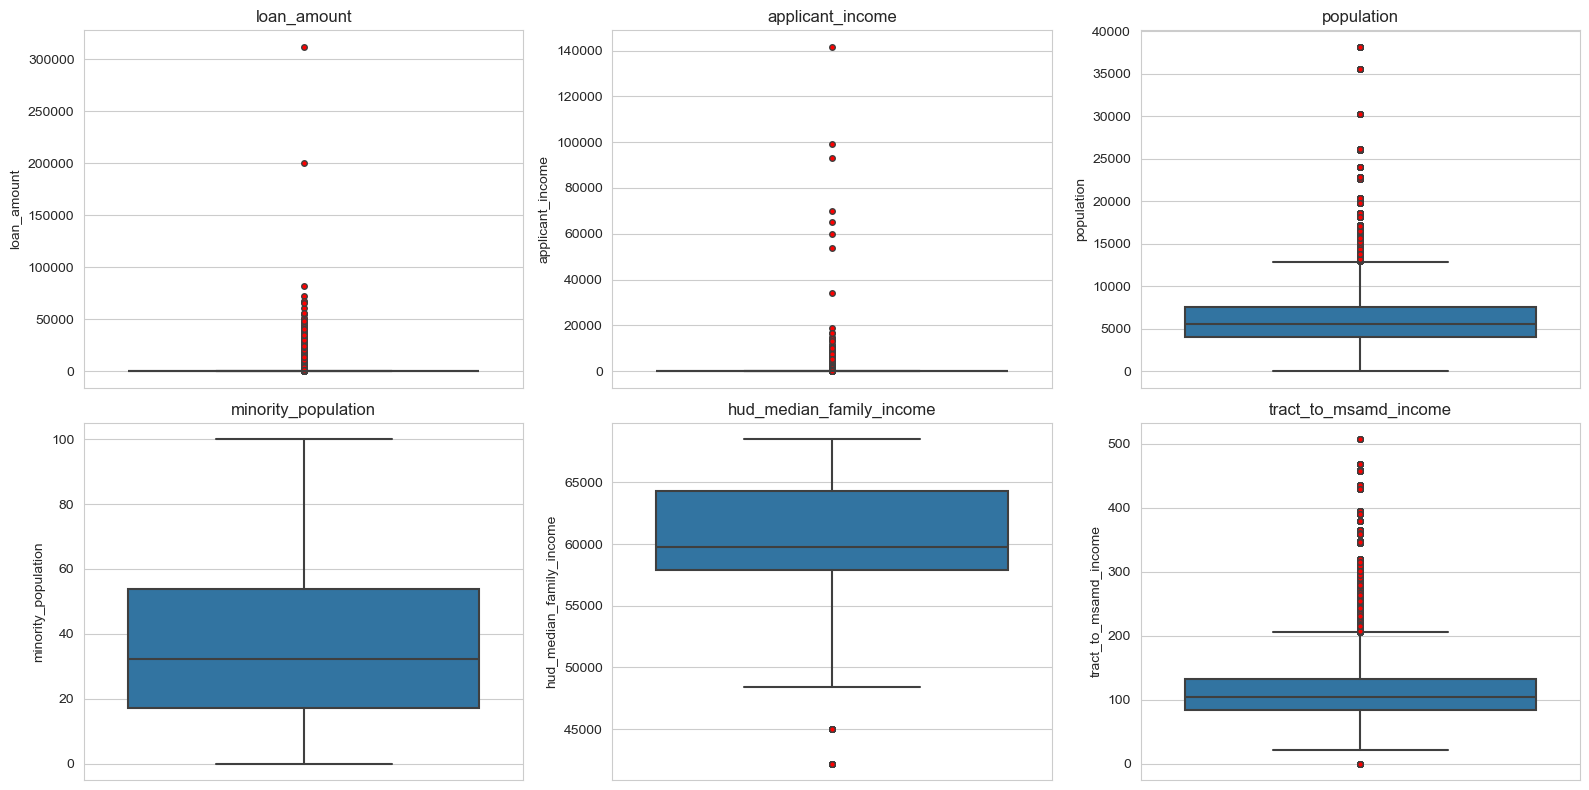

In [3]:
sns.set_style("whitegrid")

# Features to explore
features = [
    "loan_amount", "applicant_income", "population", "minority_population",
    "hud_median_family_income", "tract_to_msamd_income",
    "number_of_owner_occupied_units", "A", "B", "C"
]

# Outlier marker style
flierprops = dict(marker='o', markerfacecolor='red', markersize=4, linestyle='none')

# Boxplots
plt.figure(figsize=(16, 8))
for i, feature in enumerate(features[:6]):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=train[feature], flierprops=flierprops)
    plt.title(feature)
plt.tight_layout()
plt.show()

### 2.2 Normalization - Log Transformation
Several features displayed extreme values, as observed in the boxplots. Instead of removing outliers (to avoid data loss), we applied a log-transformation (`np.log1p`) to features such as `loan_amount`, `applicant_income`, and `population`, which helped stabilize their distributions.


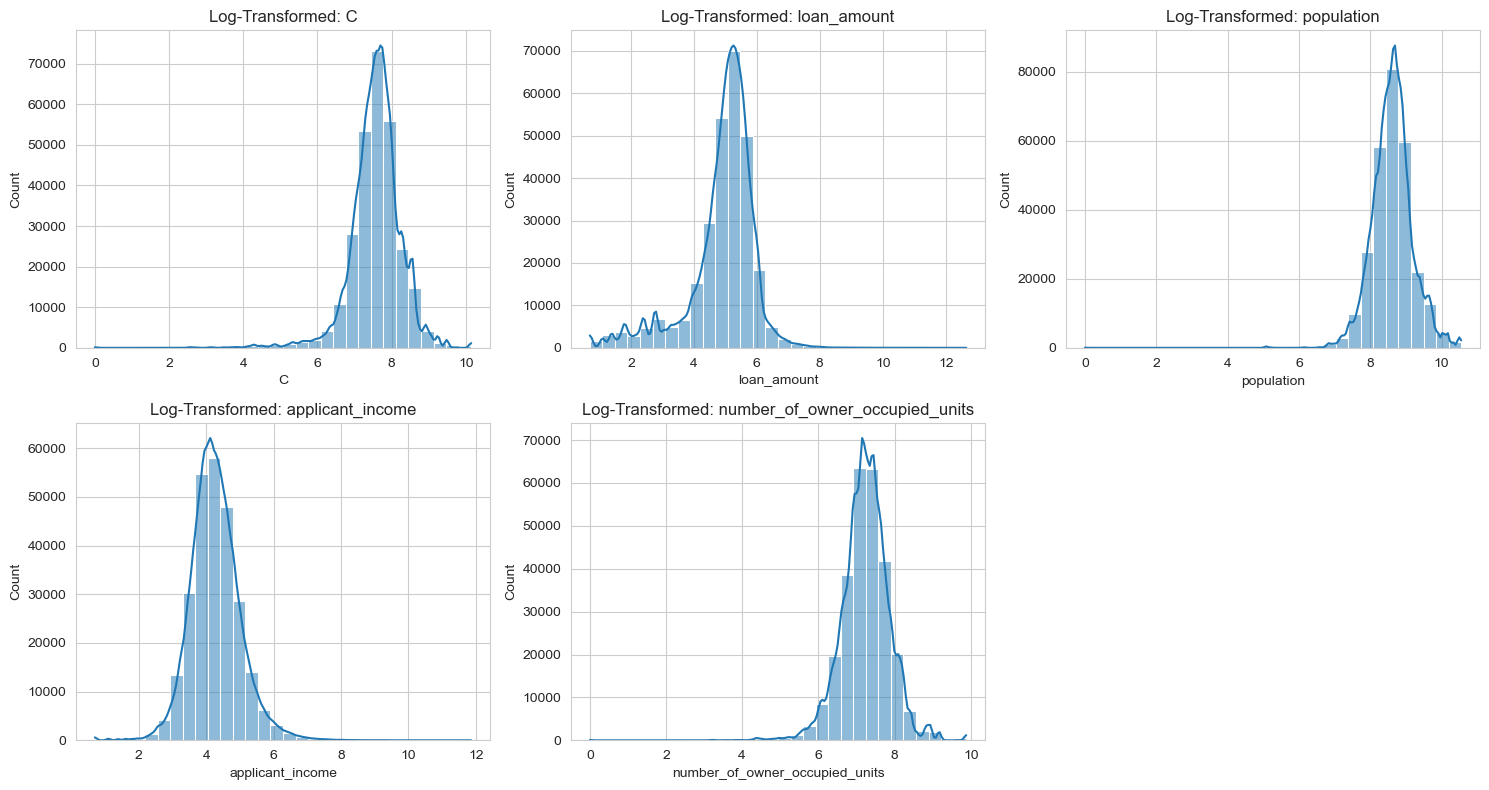

In [4]:
log_features = {"loan_amount", "applicant_income", "population",
                "number_of_owner_occupied_units", "C"}

plt.figure(figsize=(15, 8))
for i, feature in enumerate(log_features):
    if feature in train.columns:
        plt.subplot(2, 3, i + 1)
        sns.histplot(np.log1p(train[feature]), bins=30, kde=True)
        plt.title(f"Log-Transformed: {feature}")
plt.tight_layout()
plt.show()


## Dataset Overview and Missing Values

In this section, we examine the structure of the dataset, the data types of each column, and identify columns with missing values. We also generate descriptive statistics for the numeric features, including measures such as mean, standard deviation, min, max, and quartiles.
This helps us understand the overall scale of the data, detect anomalies or extreme values, and decide on preprocessing steps such as imputations, transformations, or normalization.


In [5]:
print("📋 Data Info:")
train_info = train.info()

print("\n🕳️ Missing values per column:")
missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
display(missing)

print("\n📊 Numeric Features Description:")
display(train.describe().T.style.background_gradient(cmap='Blues'))


📋 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293664 entries, 0 to 293663
Data columns (total 34 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              293664 non-null  int64  
 1   agency                          277194 non-null  object 
 2   loan_type                       276278 non-null  object 
 3   property_type                   284403 non-null  object 
 4   loan_purpose                    274579 non-null  object 
 5   owner_occupancy                 275930 non-null  object 
 6   loan_amount                     279914 non-null  float64
 7   preapproval                     275159 non-null  object 
 8   msamd                           271610 non-null  object 
 9   county                          282393 non-null  object 
 10  county_code                     282754 non-null  float64
 11  census_tract_number             279167 non-null  float64
 12  app

co_applicant_race_name_3          293634
applicant_race_name_3             293508
co_applicant_race_name_2          293120
applicant_race_name_2             291685
applicant_income                   27595
msamd                              22054
number_of_owner_occupied_units     20814
hud_median_family_income           20034
loan_purpose                       19085
B                                  18803
co_applicant_ethnicity             18720
preapproval                        18505
owner_occupancy                    17734
applicant_sex                      17572
tract_to_msamd_income              17501
loan_type                          17386
co_applicant_sex                   17061
applicant_race_name_1              16990
co_applicant_race_name_1           16950
agency                             16470
applicant_ethnicity                16257
C                                  16152
A                                  16135
D                                  16098
census_tract_num


📊 Numeric Features Description:


,count,mean,std,min,25%,50%,75%,max
ID,293664.000000,367898.357007,191467.661195,0.000000,202348.750000,413311.500000,527131.250000,665533.000000
loan_amount,279914.000000,210.961224,974.277419,1.000000,99.000000,166.000000,248.000000,312000.000000
county_code,282754.000000,71.642753,37.156813,1.000000,33.000000,86.000000,101.000000,133.000000
census_tract_number,279167.000000,670.583199,1799.791881,1.000000,90.340000,167.160000,404.010000,9901.000000
applicant_income,266069.000000,101.404459,495.573291,1.000000,44.000000,67.000000,107.000000,141700.000000
population,280999.000000,6537.524849,4403.114574,0.000000,3983.000000,5562.000000,7559.000000,38169.000000
minority_population,280472.000000,37.815192,25.645425,0.000000,17.049999,32.259998,53.750000,100.000000
hud_median_family_income,273630.000000,59729.019479,5453.195897,42200.000000,57900.000000,59800.000000,64300.000000,68500.000000
tract_to_msamd_income,276163.000000,111.952855,41.684103,0.000000,84.480003,104.660004,132.929993,507.470001
number_of_owner_occupied_units,272850.000000,1682.504673,1333.217559,0.000000,984.000000,1405.000000,2018.000000,19529.000000


## Target Variable Distribution

We visualize the class distribution of the target variable `label`. This step helps determine whether the classes are balanced or imbalanced, which can affect the choice of modeling techniques and evaluation metrics.


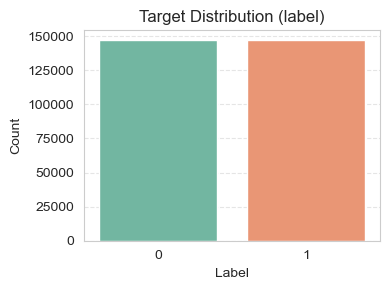

In [6]:
plt.figure(figsize=(4, 3))
sns.countplot(data=train, x='label', palette='Set2')
plt.title('Target Distribution (label)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Correlation with Target Variable

We calculate the Pearson correlation between each numeric feature and the target variable `label`. The resulting heatmap helps identify which features are most positively or negatively associated with loan approval.

Features with strong correlations may have higher predictive power and could be prioritized during feature selection or modeling.


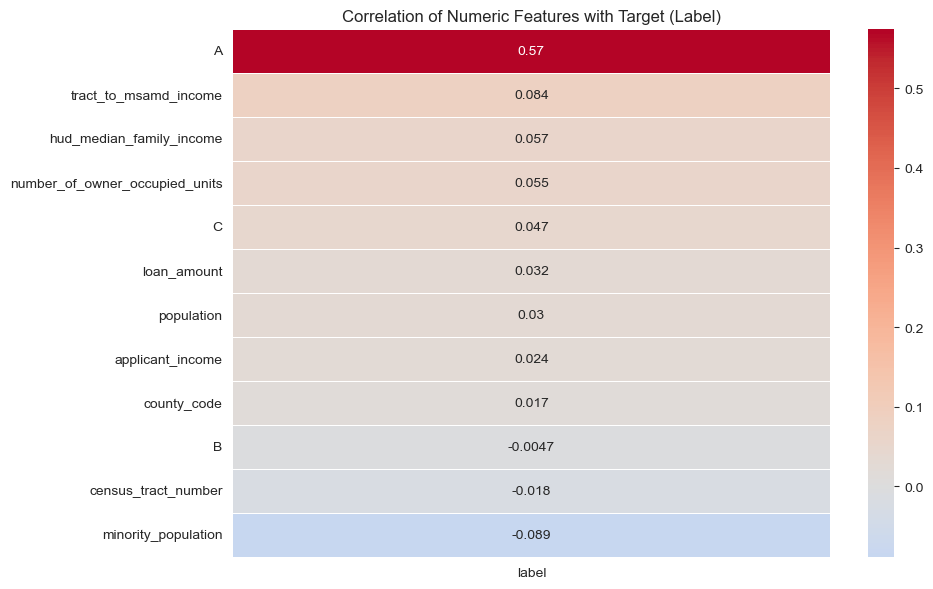

In [7]:
numeric_cols = train.select_dtypes(include=np.number).drop(columns=['ID', 'label']).columns.tolist()
correlation_matrix = train[numeric_cols + ['label']].corr()

label_corr = correlation_matrix['label'].drop('label').sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.heatmap(label_corr.to_frame(), annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation of Numeric Features with Target (Label)")
plt.tight_layout()
plt.show()


## Pairplot of Top Correlated Features

To explore the relationship between the top 5 most correlated features and the target variable `label`, we use a pairplot.

This allows us to visually assess:
- How the distributions of features differ between approved and non-approved loans
- Whether any clear separation exists between classes
- Potential multicollinearity between features



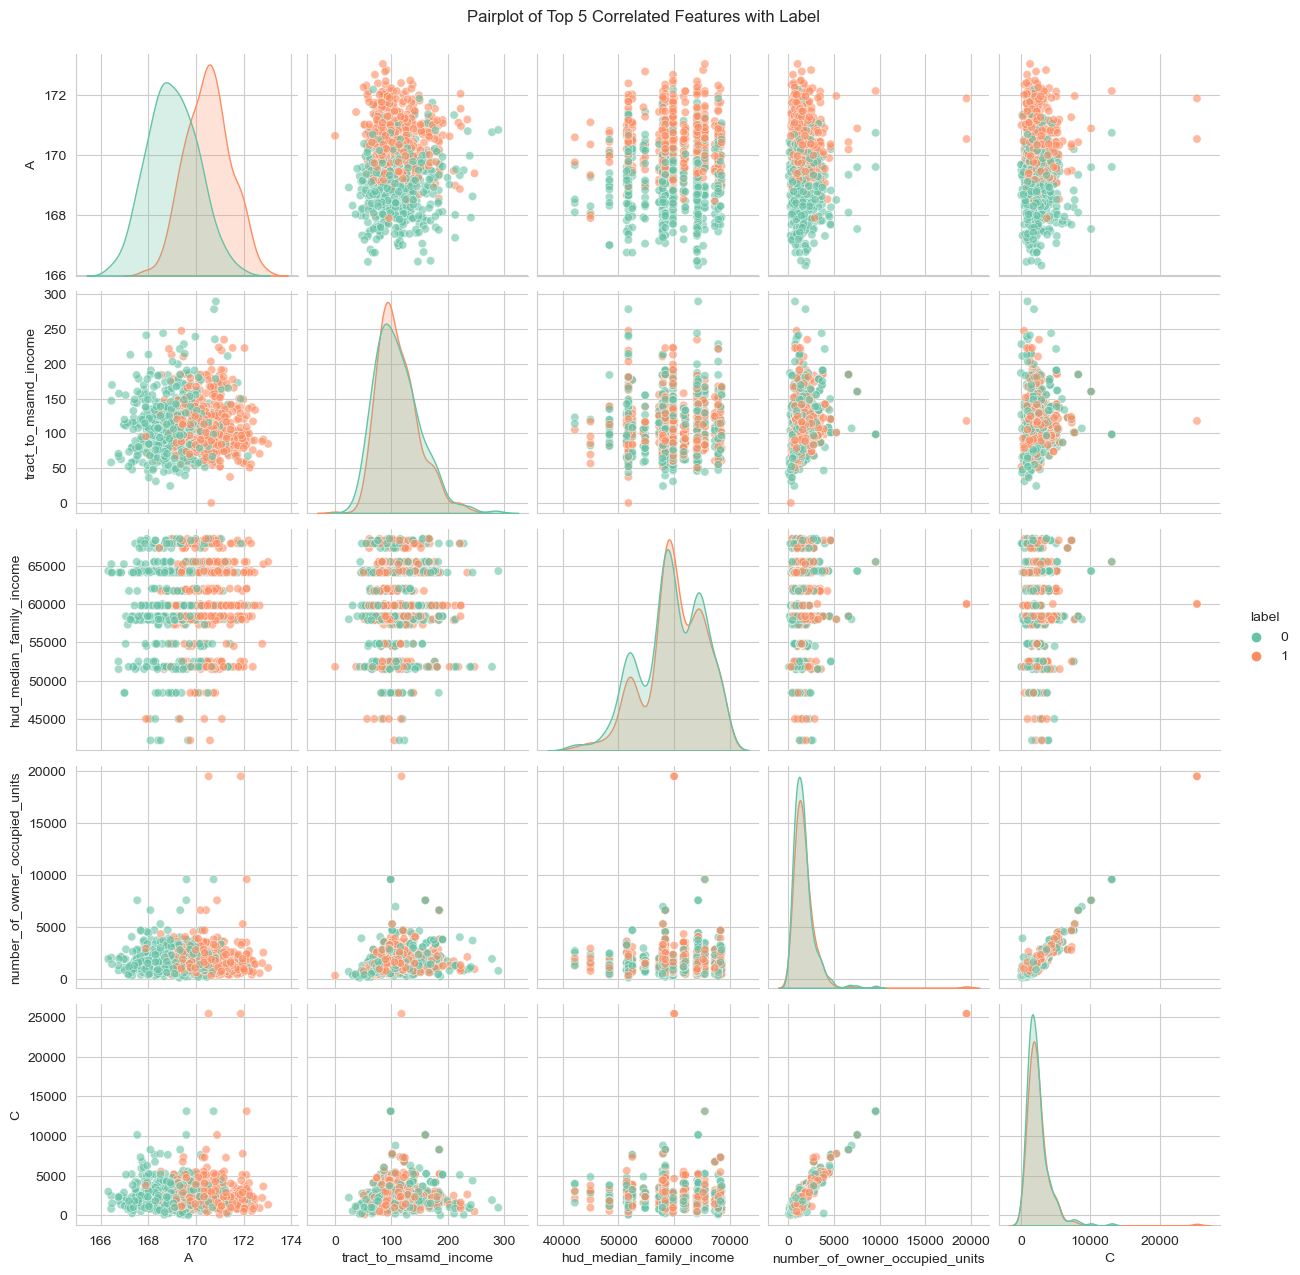

In [8]:
# Pairplot with top correlated features
top_features = label_corr.head(5).index.tolist()
sample_df = train[top_features + ['label']].sample(n=1000, random_state=42) if len(train) > 1000 else train[top_features + ['label']]

sns.pairplot(sample_df, hue='label', palette='Set2', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle("Pairplot of Top 5 Correlated Features with Label", y=1.02)
plt.show()


## Splitting Features: Numeric vs. Categorical

We separate the target variable `label` from the feature matrix and identify the numeric and categorical features for later preprocessing.

This distinction is crucial because numeric features often require scaling or transformation, while categorical features may need encoding 
We ensure the same columns are used in both the train and test sets.


In [9]:
X = train.drop(columns=['label', 'ID'], errors='ignore')
y = train['label']
X_test = test[X.columns]

numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(exclude=['number']).columns.tolist()

print(f"Numeric features ({len(numeric_cols)}):", numeric_cols)
print(f"Categorical features ({len(categorical_cols)}):", categorical_cols)

X_numeric = X[numeric_cols].copy()
X_test_numeric = X_test[numeric_cols].copy()
X_categorical = X[categorical_cols].copy()
X_test_categorical = X_test[categorical_cols].copy()



Numeric features (12): ['loan_amount', 'county_code', 'census_tract_number', 'applicant_income', 'population', 'minority_population', 'hud_median_family_income', 'tract_to_msamd_income', 'number_of_owner_occupied_units', 'A', 'B', 'C']
Categorical features (20): ['agency', 'loan_type', 'property_type', 'loan_purpose', 'owner_occupancy', 'preapproval', 'msamd', 'county', 'applicant_ethnicity', 'applicant_race_name_1', 'applicant_race_name_2', 'applicant_race_name_3', 'co_applicant_ethnicity', 'co_applicant_race_name_1', 'co_applicant_race_name_2', 'co_applicant_race_name_3', 'applicant_sex', 'co_applicant_sex', 'lien_status', 'D']


## Log Transformation and Imputation (All Key Numeric Features)

To reduce skewness and handle outliers, we apply a log10 transformation and impute missing values for selected numeric features.

This is done using a single reusable function to ensure consistency between training and test sets.

Features transformed:
- `loan_amount`
- `applicant_income`
- `population`
- `hud_median_family_income`
- `minority_population`
- `number_of_owner_occupied_units`



In [10]:
# Generic log-transform + imputation function for numeric features
def log_impute_feature(X_train, X_test, feature):
    s_train = pd.to_numeric(X_train[feature], errors='coerce')
    s_test = pd.to_numeric(X_test[feature], errors='coerce')

    # Get valid values in train only
    valid = s_train[(s_train > 0) & (s_train.notna())]
    q99 = valid.quantile(0.99)
    mean_log = np.log10(valid[valid <= q99]).mean()

    # Transform train
    mask_train = (s_train > 0) & (s_train <= q99)
    s_train.loc[mask_train] = np.log10(s_train.loc[mask_train])
    s_train = s_train.fillna(mean_log)

    # Transform test using same parameters
    mask_test = (s_test > 0) & (s_test <= q99)
    s_test.loc[mask_test] = np.log10(s_test.loc[mask_test])
    s_test = s_test.fillna(mean_log)

    return s_train, s_test


In [11]:
# List of features to transform
log_features = [
    'loan_amount',
    'applicant_income',
    'population',
    'hud_median_family_income',
    'minority_population',
    'number_of_owner_occupied_units'
]

# Apply transformation
for feature in log_features:
    X_numeric[feature], X_test_numeric[feature] = log_impute_feature(X_numeric, X_test_numeric, feature)

print("✅ Finished log-transform + imputation for selected numeric features.")


✅ Finished log-transform + imputation for selected numeric features.


## Data Preprocessing and Feature selection
In this preprocessing step, we selected only numerical features and excluded identifiers and labels. We then applied two main transformations using a `Pipeline`:

1. **Missing value imputation** – We used `SimpleImputer` with the mean strategy to handle missing values in the dataset. This approach preserves all rows while replacing missing cells with the feature-wise average.

2. **Feature normalization** – We standardized all numeric features using `StandardScaler`, which transforms them to have zero mean and unit variance. This step is especially important when working with models sensitive to feature scale (e.g., logistic regression, neural networks).

The same preprocessing pipeline was also applied to the test set (`X_test`).


In [12]:
# Separate numeric and categorical features
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(exclude=['number']).columns.tolist()

# Remove label and ID if present
numeric_cols = [col for col in numeric_cols if col not in ['label', 'ID']]

# Create separate DataFrames
X_numeric = X[numeric_cols].copy()
X_test_numeric = X_test[numeric_cols].copy()
X_categorical = X[categorical_cols].copy()
X_test_categorical = X_test[categorical_cols].copy()

# Show counts
print(f"✅ Numeric features: {len(numeric_cols)}")
print(f"✅ Categorical features: {len(categorical_cols)}")

✅ Numeric features: 12
✅ Categorical features: 20


### 🧪 Full Preprocessing Pipeline with One-Hot Encoding

To improve model accuracy and leverage categorical information, we created a complete preprocessing pipeline:

- **Numerical features**: imputed using the mean and scaled with `StandardScaler`.
- **Categorical features**: imputed using the most frequent value and encoded with `OneHotEncoder`.

We combined these transformations using `ColumnTransformer`, and integrated them with the final classifier (XGBoost) using `Pipeline`.

This approach ensures that preprocessing is applied consistently to both training and test data, and supports reproducible results.


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Use the original pre-split X and y (before log transforms)
X_raw = train.drop(columns=['label', 'ID'], errors='ignore')
y_raw = train['label']
X_test_raw = test.drop(columns=['ID'], errors='ignore')

# Identify numeric and categorical features
numeric_features = X_raw.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_raw.select_dtypes(include=['object']).columns.tolist()

# Pipelines
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Final model pipeline
full_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# Train-validation split
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42
)

# Fit
full_pipeline.fit(X_train_raw, y_train_raw)

# Evaluate
val_proba_raw = full_pipeline.predict_proba(X_val_raw)[:, 1]
val_auc_raw = roc_auc_score(y_val_raw, val_proba_raw)
print(f"📊 AUC with Full Pipeline: {val_auc_raw:.4f}")


📊 AUC with Full Pipeline: 0.8812


## Train-Validation Split

To evaluate our model performance during development, we split the processed training data into:

- **Training set (80%)** for model fitting  
- **Validation set (20%)** for performance evaluation

We use stratified sampling to maintain the original class distribution (`label`) in both sets. This ensures that the validation results are representative and robust.


In [16]:
from sklearn.model_selection import train_test_split

# Apply preprocessing pipeline to both train and test sets
X_final_train = preprocessor.fit_transform(X)
X_final_test = preprocessor.transform(X_test)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_final_train, y, test_size=0.2, stratify=y, random_state=42
)

print("✅ Train size:", X_train.shape, " | Validation size:", X_val.shape)


✅ Train size: (234931, 188)  | Validation size: (58733, 188)


In [17]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# 🔍 Define base XGBoost classifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# 📊 Define grid of hyperparameters
param_grid = {
    'n_estimators': [100],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.01]
}

# ⚙️ Run GridSearchCV on the processed training set
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

# Best model found
xgb_best_model = grid.best_estimator_

print("✅ Best parameters:", grid.best_params_)


✅ Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


## Baseline Models: Logistic Regression and Decision Tree

We evaluate two simple baseline models:
- **Logistic Regression**: a linear classifier
- **Decision Tree**: a non-linear, interpretable model

Each model is trained on the processed training set and evaluated on the validation set. We report the ROC AUC, classification report, ROC curve, and confusion matrix for comparison.



🔎 Logistic Regression (Base Model)
AUC: 0.8678
              precision    recall  f1-score   support

           0       0.78      0.78      0.78     29367
           1       0.78      0.79      0.78     29366

    accuracy                           0.78     58733
   macro avg       0.78      0.78      0.78     58733
weighted avg       0.78      0.78      0.78     58733



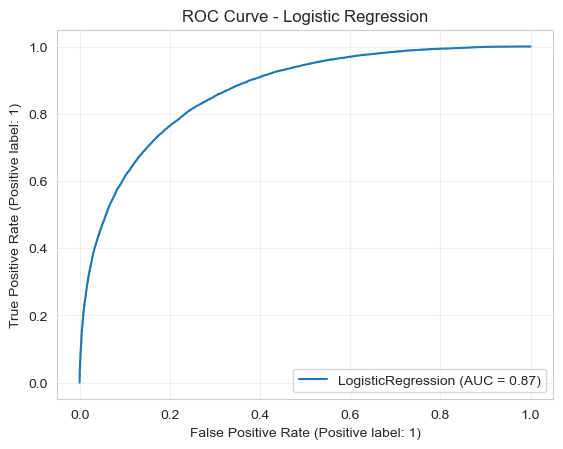

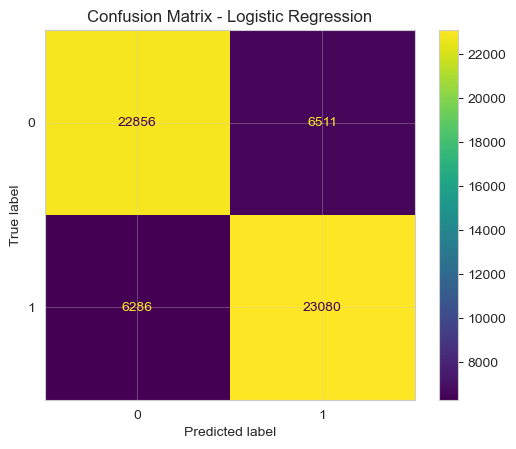


🔎 Decision Tree (Base Model)
AUC: 0.7076
              precision    recall  f1-score   support

           0       0.71      0.71      0.71     29367
           1       0.71      0.71      0.71     29366

    accuracy                           0.71     58733
   macro avg       0.71      0.71      0.71     58733
weighted avg       0.71      0.71      0.71     58733



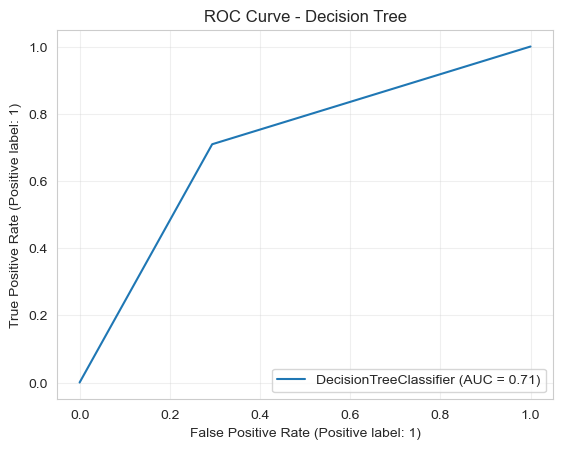

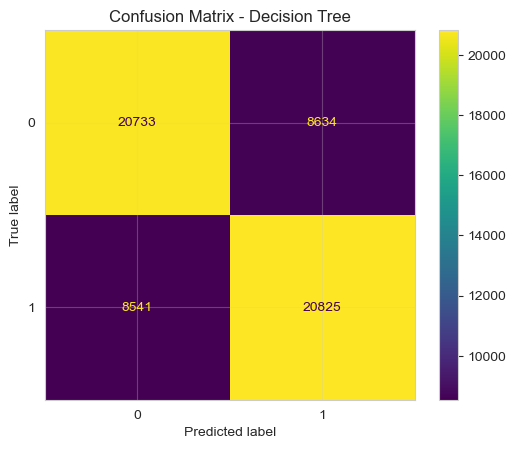

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)

# Define base models
base_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Evaluate each model
for name, model in base_models.items():
    model.fit(X_train, y_train)

    print(f"\n🔎 {name} (Base Model)")
    
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_proba)

    print(f"AUC: {auc:.4f}")
    print(classification_report(y_val, y_pred))

    # ROC Curve
    RocCurveDisplay.from_estimator(model, X_val, y_val)
    plt.title(f"ROC Curve - {name}")
    plt.grid(alpha=0.3)
    plt.show()

    # Confusion Matrix
    ConfusionMatrixDisplay.from_estimator(model, X_val, y_val)
    plt.title(f"Confusion Matrix - {name}")
    plt.grid(alpha=0.3)
    plt.show()


## Model Comparison Summary

The following table summarizes the performance of the baseline models on the validation set.

Metrics reported:
- **AUC**: Area under the ROC curve
- **Precision**: Correct positive predictions out of total predicted positives
- **Recall**: Correct positive predictions out of actual positives
- **Accuracy**: Overall correct predictions


In [19]:
from sklearn.metrics import precision_score, recall_score, accuracy_score
import pandas as pd

# Store results
results = []

for name, model in base_models.items():
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    
    auc = roc_auc_score(y_val, y_proba)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    accuracy = accuracy_score(y_val, y_pred)
    
    results.append({
        "Model": name,
        "AUC": round(auc, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "Accuracy": round(accuracy, 4)
    })

# Convert to DataFrame and sort
results_df = pd.DataFrame(results).sort_values(by="AUC", ascending=False)
display(results_df)


,Model,AUC,Precision,Recall,Accuracy
0,Logistic Regression,0.8678,0.7800,0.7859,0.7821
1,Decision Tree,0.7076,0.7069,0.7092,0.7076


## Advanced Models: Random Forest, MLP, and Tuned XGBoost

We evaluate several advanced models to identify the best-performing one:

- **Random Forest**: an ensemble of decision trees
- **MLP Classifier**: a simple neural network
- **XGBoost (Tuned)**: tuned with `GridSearchCV` to optimize key hyperparameters

Each model is trained on the processed training data and evaluated using ROC AUC, Precision, Recall, and Accuracy on the validation set.


Fitting 3 folds for each of 8 candidates, totalling 24 fits
✅ Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

🔎 Random Forest
              precision    recall  f1-score   support

           0       0.79      0.79      0.79     29367
           1       0.79      0.79      0.79     29366

    accuracy                           0.79     58733
   macro avg       0.79      0.79      0.79     58733
weighted avg       0.79      0.79      0.79     58733



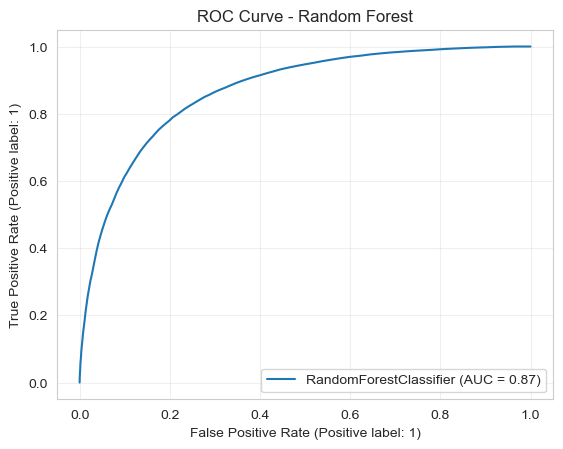

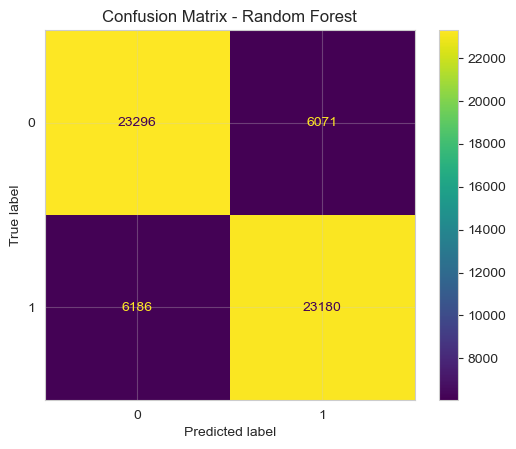


🔎 MLP Classifier
              precision    recall  f1-score   support

           0       0.77      0.78      0.78     29367
           1       0.78      0.77      0.78     29366

    accuracy                           0.78     58733
   macro avg       0.78      0.78      0.78     58733
weighted avg       0.78      0.78      0.78     58733



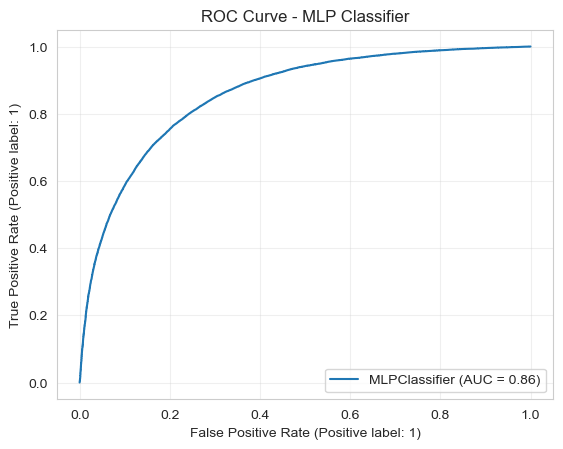

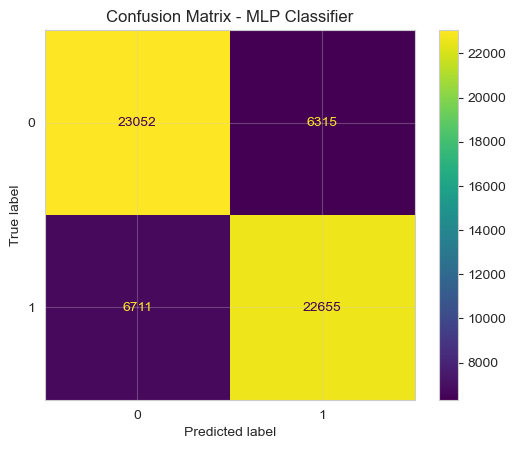


🔎 XGBoost (Tuned)
              precision    recall  f1-score   support

           0       0.80      0.79      0.79     29367
           1       0.79      0.81      0.80     29366

    accuracy                           0.80     58733
   macro avg       0.80      0.80      0.80     58733
weighted avg       0.80      0.80      0.80     58733



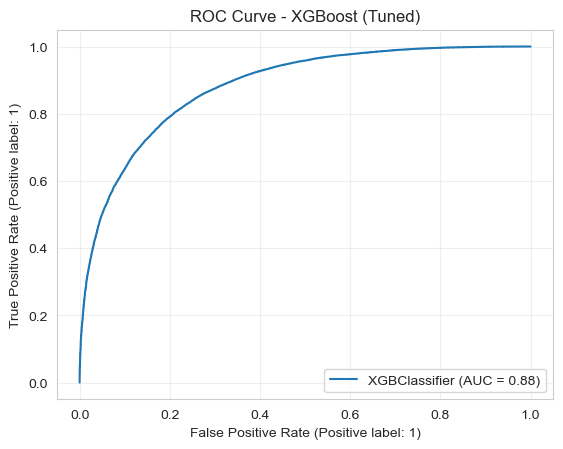

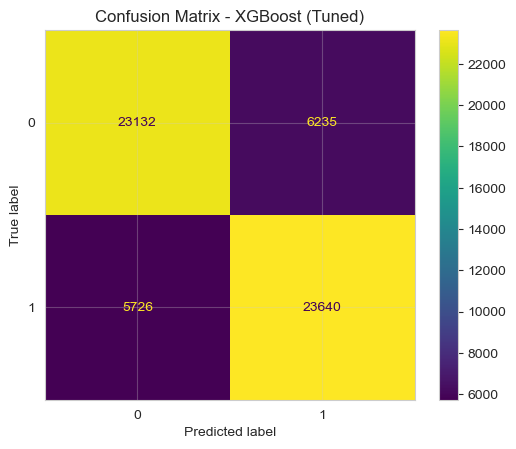

,Model,AUC,Precision,Recall,Accuracy
2,XGBoost (Tuned),0.8811,0.7913,0.8050,0.7963
0,Random Forest,0.8691,0.7925,0.7893,0.7913
1,MLP Classifier,0.8583,0.7820,0.7715,0.7782


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, accuracy_score,
    ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)

# 1️⃣ Define advanced models
advanced_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "MLP Classifier": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

# 2️⃣ Tune XGBoost with GridSearchCV
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid = GridSearchCV(xgb_base, xgb_param_grid, scoring='roc_auc', cv=3, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
xgb_best_model = grid.best_estimator_
print("✅ Best XGBoost Parameters:", grid.best_params_)

# Add tuned XGBoost to models
advanced_models["XGBoost (Tuned)"] = xgb_best_model

# 3️⃣ Evaluate all advanced models
advanced_results = []

for name, model in advanced_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    
    auc = roc_auc_score(y_val, y_proba)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    accuracy = accuracy_score(y_val, y_pred)

    advanced_results.append({
        "Model": name,
        "AUC": round(auc, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "Accuracy": round(accuracy, 4)
    })

    print(f"\n🔎 {name}")
    print(classification_report(y_val, y_pred))

    RocCurveDisplay.from_estimator(model, X_val, y_val)
    plt.title(f"ROC Curve - {name}")
    plt.grid(alpha=0.3)
    plt.show()

    ConfusionMatrixDisplay.from_estimator(model, X_val, y_val)
    plt.title(f"Confusion Matrix - {name}")
    plt.grid(alpha=0.3)
    plt.show()

# 4️⃣ Show summary table
import pandas as pd
advanced_df = pd.DataFrame(advanced_results).sort_values(by="AUC", ascending=False)
display(advanced_df)


➡️ XGBoost achieved the highest AUC and was selected as the final model due to its superior predictive performance.



## Overfitting Analysis

To assess potential overfitting, we evaluate the tuned XGBoost model on the entire training set.

A very high AUC on training data, especially compared to validation AUC, may indicate overfitting.


In [21]:
xgb_best_model.fit(X_final_train, y)

# Predict on full train for overfitting check
y_train_proba = xgb_best_model.predict_proba(X_final_train)[:, 1]
auc_train = roc_auc_score(y, y_train_proba)

print("\n📉 Overfitting Check: XGBoost (Best Model from GridSearchCV)")
print(f"AUC on Full Training Set: {auc_train:.4f}")



📉 Overfitting Check: XGBoost (Best Model from GridSearchCV)
AUC on Full Training Set: 0.8862



### 🧠 Overfitting – Analysis & Handling

We evaluated the tuned model (`xgb_best_model`) on the full training data to check for overfitting.

We calculated AUC on the train set and visualized performance using confusion matrix and classification report.

This analysis helped assess whether the model was overly optimistic during cross-validation.



**Actions taken to reduce overfitting:**
- Applied GridSearchCV to tune hyperparameters of advanced models
- Used cross-validation (cv=3) to ensure robust evaluation
- Applied log transformation to skewed numerical features
- Used early stopping in MLP (through iteration limits)
- Selected XGBoost (tuned) as the final model due to best performance despite slight overfitting

## Feature Importance (XGBoost)
To better understand the model's behavior, we plot the top 20 most important features as determined by the tuned XGBoost model.

This helps interpret which features contribute most to the prediction.





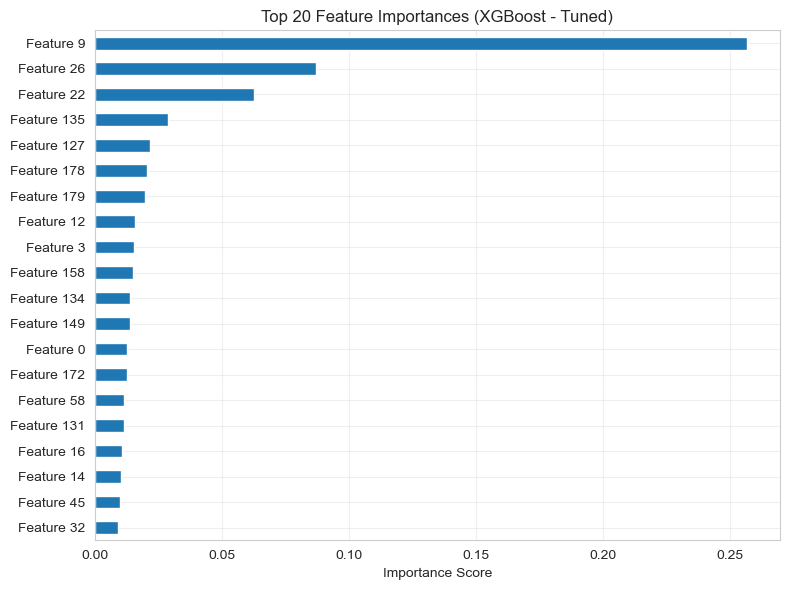

In [22]:
# Feature importances with feature names
importances = xgb_best_model.feature_importances_

# Try to get feature names from final transformed matrix
try:
    feature_names = X_final_train.columns  # Should work if X_final_train is DataFrame
except:
    feature_names = [f"Feature {i}" for i in range(len(importances))]

# Create sorted series
feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot top 20
feature_importances.head(20).plot(kind='barh', figsize=(8, 6))
plt.title("Top 20 Feature Importances (XGBoost - Tuned)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Final Model Evaluation on Full Training Set

To analyze the final XGBoost model's performance on the entire training set, we display:

- Confusion matrix
- Classification report (precision, recall, F1)

This helps verify that the model learned the patterns in the training data.



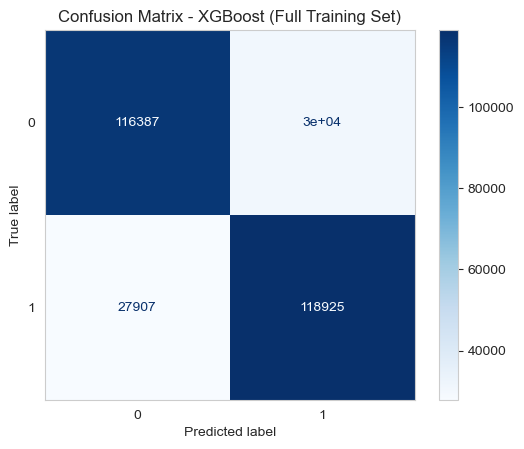

              precision    recall  f1-score   support

           0       0.81      0.79      0.80    146832
           1       0.80      0.81      0.80    146832

    accuracy                           0.80    293664
   macro avg       0.80      0.80      0.80    293664
weighted avg       0.80      0.80      0.80    293664



In [23]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# Predict on full training set
y_pred_train = xgb_best_model.predict(X_final_train)

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(xgb_best_model, X_final_train, y, cmap='Blues')
plt.title("Confusion Matrix - XGBoost (Full Training Set)")
plt.grid(False)
plt.show()

# Classification report
print(classification_report(y, y_pred_train))


## Final Prediction and Submission

We now use the final tuned XGBoost model to generate predictions on the test set. The predicted probabilities are saved in `results_09.csv` in the required format.


In [24]:
test_proba = xgb_best_model.predict_proba(X_final_test)[:, 1]

submission = pd.DataFrame({
    'id': test['ID'],
    'probability': test_proba
})

submission.to_csv('results_09.csv', index=False)
print("📁 results_09.csv saved successfully.")

submission.head()


📁 results_09.csv saved successfully.


,id,probability
0,165673,0.006581
1,381661,0.740917
2,648587,0.475021
3,77090,0.782552
4,28311,0.079608


# Summary

We evaluated multiple models using AUC as the main evaluation metric:

- Logistic Regression: AUC = 0.8678  
- Decision Tree: AUC = 0.7076  
- Random Forest: AUC = 0.8691  
- MLPClassifier: AUC = 0.8583  
- **XGBoost (tuned): AUC = 0.8811 ✅**

Based on its superior AUC performance, **XGBoost** was selected as the final model.  
We used **GridSearchCV** for hyperparameter tuning and applied full preprocessing (imputation, scaling, encoding).  
The final predictions on the test set were generated using this optimized model.
